# Project 3: Advection-diffusion equations

Put a drop of ink in a river. The flow carries it downstream while it slowly spreads out, and if the ink
reacted chemically with the water it could also grow or fade away. These three effects, *advection*,
*diffusion* and *reaction*, are described by the one-dimensional advection-diffusion equation

\begin{equation}
  \frac{\partial u}{\partial t} + V \frac{\partial u}{\partial x} = D \frac{\partial^2 u}{\partial x^2} + f(u)
  \tag{1}
\end{equation}

for a field $u(x, t)$ defined on a domain $x \in [0, L]$. Here $V$ is the advection velocity, $D$ the diffusion
coefficient and $f(u)$ a source term (losses, a chemical reaction, a nonlinear saturation...). We are given the
initial condition $u(x, 0) = u_0(x)$ and boundary conditions at $x = 0$ and $x = L$, which depend on the physical
problem:

- periodic: $u(0, t) = u(L, t)$
- Neumann: $\partial_x u(0, t) = \alpha$ and $\partial_x u(L, t) = \beta$ (for $\alpha = \beta = 0$, nothing flows in or out)
- Dirichlet: $u(0, t) = \alpha$ and $u(L, t) = \beta$

Equation (1) shows up all over physics: the heat equation ($u$ is the temperature), the transport of a tracer in
a fluid ($u$ is a concentration), the propagation of a laser pulse in an optical fiber ($u$ is the envelope of the
electric field and $D$ is imaginary), the time-dependent Schrödinger equation ($u$ is the wave function and
$D = i\hbar/2m$), or the Ginzburg-Landau equation ($u$ is the amplitude of a pattern, e.g. convection rolls).

In this project we will learn two general methods to integrate such *parabolic* partial differential equations:

- **Part 1**: a spectral method, based on Fourier transforms, very accurate for linear problems with periodic boundary conditions,
- **Part 2**: the Crank-Nicolson finite-difference scheme, which handles any boundary condition and nonlinear terms,

and then use them to explore some beautiful physics: invading fronts (**Part 3**) and spatiotemporal chaos in the
complex Ginzburg-Landau equation (**Part 4**).

In [30]:
# Common imports
%matplotlib inline
from collections.abc import Callable

import numpy as np
import scipy.linalg as la

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.image import AxesImage

# the random number generator
rng = np.random.default_rng(seed=2026)

# colormaps: sequential for u >= 0, diverging for signed fields, cyclic for phases
SEQ_CMAP = LinearSegmentedColormap.from_list("sequential", ["#f7f6f3", "#56B4E9", "#0072B2", "#0b2545"])
DIV_CMAP = LinearSegmentedColormap.from_list("diverging", ["#0072B2", "#f0efec", "#D55E00"])
PHASE_CMAP = "twilight"

# to draw a field u(x, t) as a space-time map
def show_spacetime(x: np.ndarray, t: np.ndarray, u: np.ndarray, ax: plt.Axes | None = None,
                   cmap=SEQ_CMAP, label: str | None = None, **kwargs) -> AxesImage:
    """Draw u[n, j] = u(x_j, t_n) as a map, with x horizontal and t increasing upwards."""
    ax = ax if ax is not None else plt.gca()
    image = ax.imshow(u, origin="lower", aspect="auto", cmap=cmap,
                      extent=(x[0], x[-1], t[0], t[-1]), **kwargs)
    ax.set(xlabel="$x$", ylabel="$t$")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.figure.colorbar(image, ax=ax, label=label, pad=0.02)
    return image

## Part 1: The spectral method

Let us start with one of the simplest and most accurate ways to integrate a partial differential equation: a
*spectral method*, where the solution is decomposed into Fourier modes

\begin{equation}
  \hat u(k, t) = \int_{-\infty}^{+\infty} u(x, t)\, e^{-ikx}\, dx
  \qquad
  u(x, t) = \frac{1}{2\pi} \int_{-\infty}^{+\infty} \hat u(k, t)\, e^{ikx}\, dk
\end{equation}

The Fourier basis is naturally suited to periodic boundary conditions. Here we consider a pulse in an infinite
domain, and we simply choose a numerical box large enough that the periodic copies of the pulse do not see each
other. We also take $f(u) = 0$. The magic of Fourier modes is that $e^{ikx}$ is an eigenfunction of both
$\partial_x$ and $\partial_x^2$: in Fourier space, Eq. (1) becomes a set of independent ordinary differential
equations, one for each wavenumber $k$,

\begin{equation}
  \frac{\partial \hat u}{\partial t} = -\big(D k^2 + i V k\big)\, \hat u
  \qquad \Longrightarrow \qquad
  \hat u(k, t) = \hat u(k, 0)\, e^{-D k^2 t}\, e^{-i V k t}
  \tag{P}
\end{equation}

This solution has a nice physical reading. The factor $e^{-Dk^2t}$ damps every mode, and the short wavelengths
(large $k$) die first: diffusion smooths things out. The factor $e^{-iVkt}$ is a pure phase, it just translates
the profile by $Vt$: this is advection.

### Numerical implementation

On a computer, the Fourier transforms are replaced by their discrete versions, computed by the fast Fourier
transform (FFT) in only $O(N \log N)$ operations. We discretize time and space as

\begin{equation}
  t_n = n\, \Delta t, \qquad x_j = j\, \Delta x, \quad j = 0, \dots, N-1, \qquad \Delta x = \frac{L}{N}
\end{equation}

and write $U^n_j \simeq u(x_j, t_n)$ for the numerical solution. Note that the box is periodic, so the point
$x = L$ is the same as $x = 0$ and must not be part of the grid. The wavenumbers are

\begin{equation}
  k_m = m\, \Delta k, \quad m = -\frac{N}{2}, \dots, \frac{N}{2} - 1, \qquad \Delta k = \frac{2\pi}{N \Delta x}
\end{equation}

and the largest one is the Nyquist wavenumber $k_c = \pi / \Delta x$: a wave shorter than two grid spacings
cannot be represented on the grid.

*Note*: FFT routines store the wavenumbers in a peculiar order. For `A = np.fft.fft(a)`, the zero mode is `A[0]`,
the positive wavenumbers are in `A[1:N//2]` and the negative ones in `A[N//2:]`. The function
`np.fft.fftfreq(N, d=dx)` returns the frequencies $k / 2\pi$ in that same order.

*Note*: FFTs are fastest when $N$ is a product of small primes, ideally a power of 2.

### Algorithm

To go from $U^n$ to $U^{n+1}$:

1. Compute $\hat U^n$ by applying the FFT to $U^n$.
2. Multiply by the propagator: $\hat U^{n+1}_m = \hat U^n_m\, \exp\big(-(D k_m^2 + i V k_m)\, \Delta t\big)$.
3. Compute $U^{n+1}$ by applying the inverse FFT to $\hat U^{n+1}$.

For this linear problem we could jump from $t = 0$ to any time $t$ in a single step. Doing many small steps
becomes useful as soon as there is a source term $f(u)$, which can then be handled in real space between two
Fourier steps (this is the idea of *split-step* methods).

### 1.1 The initial condition

We will use a Gaussian pulse as initial condition. When a function has several constant parameters, it is
often convenient to use a class instead of a function: the constant parameters are given once to the
constructor `__init__` and stored in the object, while the variable $x$ is passed to the special method
`__call__`. This method makes the object *callable*: `gauss(x)` is the same as `gauss.__call__(x)`.

Write a class for the Gaussian $u_0(x) = U_0 \exp\big(-(x - x_0)^2 / \sigma^2\big)$:

```python
class Gaussian:
    """A Gaussian pulse of given width and amplitude, centered at x0."""

    def __init__(self, width: float, amplitude: float, x0: float) -> None:
        self.width = width
        ...

    def __call__(self, x: np.ndarray) -> np.ndarray:
        return ...
```

You can then create a Gaussian and use it like a function:

```python
gauss = Gaussian(width=1, amplitude=1, x0=0.5)
gauss(0.5)                       # 1.0
gauss(np.array([0, 1, 2, 3]))    # array([0.77880078, 0.77880078, 0.10539922, 0.00193045])
```

Plot your Gaussian to check that it is correct.

In [31]:
class Gaussian:
    def __init__(self,width,amplitude,x0):
        self.width = width
        self.amplitude = amplitude
        self.x0 = x0

    def __call__(self,x):
        fun = self.amplitude*np.exp(-((x-self.x0)/self.width)**2)

        return fun

In [32]:
gauss = Gaussian(width=1,amplitude=1,x0=0.5)
gauss(np.array([0,1,2]))



array([0.77880078, 0.77880078, 0.10539922])

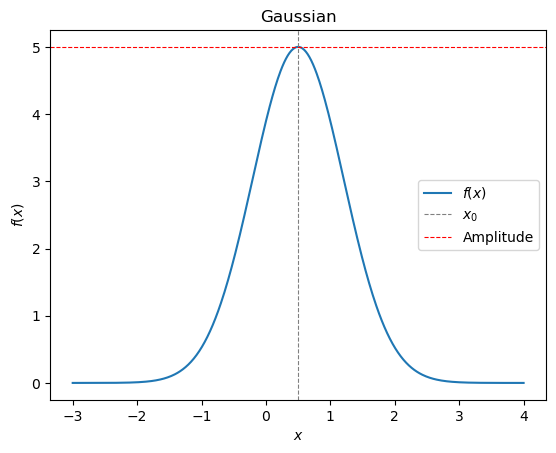

In [33]:
gauss = Gaussian(width=1, amplitude=5, x0=0.5)

x = np.linspace(-3, 4, 500)     # rango alrededor de x0, con muchos puntos para que salga suave
u = gauss(x)                    # tu __call__ funciona con arrays

fig, ax = plt.subplots()
ax.plot(x, u, label=r"$f(x)$")
ax.axvline(gauss.x0, color="gray", ls="--", lw=0.8, label=r"$x_0$")
ax.axhline(gauss.amplitude, color="red", ls="--", lw=0.8, label="Amplitude")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Gaussian")
ax.legend()
plt.show()


### 1.2 A class to advance the solution from $t$ to $t + \Delta t$

This class should create the spatial grid $x_j$ and the wavenumbers $k_m$, store the parameters $D$ and $V$, and
provide a way to set the initial condition. Its method `step(dt)` evolves $u(x, t) \to u(x, t + \Delta t)$ with
the three steps of the algorithm above:

1. transform $u(x, t) \to \hat u(k, t)$ with the FFT,
2. advance by $\Delta t$ using Eq. (P),
3. transform $\hat u(k, t + \Delta t) \to u(x, t + \Delta t)$ with the inverse FFT.

```python
class Spectral:
    def __init__(self, L: float, n_points: int, D: float, V: float) -> None:
        ...

    def initialize(self, func: Callable[[np.ndarray], np.ndarray]) -> None:
        ...

    def step(self, dt: float) -> None:
        ...
```

*Hints*: `np.linspace(0, L, n_points, endpoint=False)` creates a periodic grid without the point $x = L$.
The inverse FFT returns a complex array even if $u$ is real: its imaginary part is only round-off noise and can
be dropped.

In [34]:
class Spectral:
    def __init__(self,L,n_points,D,V):
        self.L = L
        self.n_points = n_points
        self.D = D
        self.V = V
        self.dx = L/n_points
        self.x = np.linspace(0,self.L,self.n_points,endpoint=False)
        self.k = 2*np.pi*np.fft.fftfreq(n_points,d=self.dx) # fftfreq gives k/2π
        self.t = 0.0
        self.u = None

    def initialize(self,func):
        self.u = func(self.x)
        self.t = 0.0

    def step(self,dt):
        u_hat = np.fft.fft(self.u)
        u_hat = u_hat*np.exp(-(self.D * self.k**2 + 1j * self.V * self.k)*dt)
        self.u = np.fft.ifft(u_hat).real
        self.t += dt
        



### 1.3 Time evolution

Write a function `advance(spectral, T, n_steps)` that evolves the solution from $t$ to $t + T$ using
`n_steps` steps.

In [35]:
def advance(spectral,T,n_steps):
    dt = T/n_steps

    for _ in range(n_steps):
        spectral.step(dt)

    return spectral.u



### 1.4 Check the results

1. Choose a problem that you can solve exactly, for example the pure diffusion of a tracer ($V = 0$). Starting
   from the Gaussian $u_0(x)$ above, the exact solution is

   \begin{equation}
     u(x, t) = \frac{U_0}{\sqrt{1 + 4Dt/\sigma^2}} \exp\left(-\frac{(x - x_0)^2}{\sigma^2 + 4Dt}\right)
   \end{equation}

   The pulse gets wider and lower, but its area $\int u\, dx = \sqrt{\pi}\, U_0 \sigma$ stays the same. Plot
   the numerical solution at a few times and compare with the exact solution. How does the error depend on the
   number of steps? Why?

2. Plot $|\hat U(k)|$ as a function of $k$ at a few times, on a logarithmic scale. Which modes disappear first?

3. Check the purely advective case ($D = 0$). Any function of $x - Vt$ solves $u_t + V u_x = 0$, so the pulse
   should travel without changing its shape. What happens when it reaches the edge of the box?

4. Finally, combine advection and diffusion and draw $u(x, t)$ as a space-time map using the function
   `show_spacetime` defined at the top of the notebook.

In [36]:
def gauss_exact(gauss0,D,t):
    amplitude_exact = gauss0.amplitude 
    amplitude_exact = amplitude_exact/(np.sqrt(1 + 4*D*t/gauss0.width**2))
    width_exact = np.sqrt(gauss0.width**2 + 4*D*t)

    gauss_ex = Gaussian(width=width_exact,amplitude=amplitude_exact,x0=gauss0.x0)

    return gauss_ex

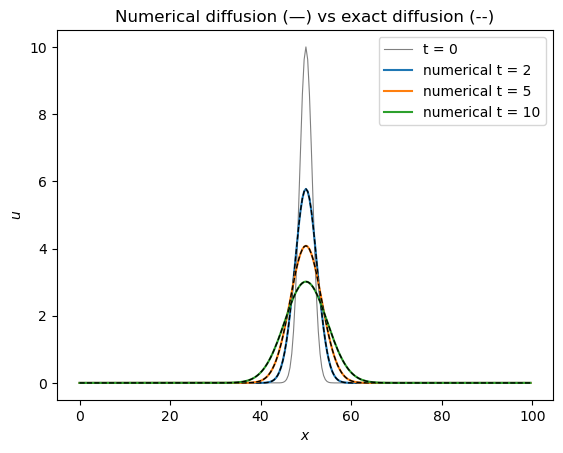

In [41]:
gauss0 = Gaussian(width=2, amplitude=10, x0=50)
sp = Spectral(L=100, n_points=256, D=1, V=0)
sp.initialize(gauss0)

fig, ax = plt.subplots()
ax.plot(sp.x, sp.u, color="gray", lw=0.8, label="t = 0")
for T in [2, 5, 10]:                       # varios instantes, como pide el enunciado
    advance(sp, T=T - sp.t, n_steps=30)    # avanza hasta t = T
    line, = ax.plot(sp.x, sp.u, label=f"numerical t = {sp.t:.0f}")
    ax.plot(sp.x, gauss_exact(gauss0, sp.D, sp.t)(sp.x), "k--", lw=1)
ax.set(xlabel="$x$", ylabel="$u$", title="Numerical diffusion (—) vs exact diffusion (--)")
ax.legend(); plt.show()


## Part 2: Finite differences and the Crank-Nicolson method

The spectral method is very accurate, but it has two limitations: it imposes periodic boundary conditions, and it
is exact only for linear equations with constant coefficients. Finite-difference methods work directly on the
grid in real space and do not have these limitations. The Crank-Nicolson (CN) scheme, initially proposed in 1947
for the heat equation, is the classic choice for parabolic equations.

We now solve Eq. (1) with Neumann boundary conditions

\begin{equation}
  \frac{\partial u}{\partial t} + V \frac{\partial u}{\partial x} = D \frac{\partial^2 u}{\partial x^2} + f(u),
  \qquad \left.\frac{\partial u}{\partial x}\right|_{x = 0} = \left.\frac{\partial u}{\partial x}\right|_{x = L} = 0
\end{equation}

A vanishing gradient at the boundaries means that there is no diffusive flux through the walls: for a
concentration, no material can enter or leave the box.

### The grid

We use regular grids in time and space,

\begin{equation}
  t_n = n\, \Delta t, \quad n = 0, \dots, N - 1, \qquad
  x_j = j\, \Delta x, \quad j = 0, \dots, J - 1, \qquad
  \Delta x = \frac{L}{J - 1}
\end{equation}

Contrary to Part 1, both boundaries $x_0 = 0$ and $x_{J-1} = L$ are now grid points. As before, the goal is to
compute numbers $U^n_j \simeq u(x_j, t_n)$.

### The Crank-Nicolson stencil

The time derivative at grid point $(j, n)$ is approximated by a forward difference

\begin{equation}
  \frac{\partial u}{\partial t} \simeq \frac{U^{n+1}_j - U^n_j}{\Delta t}
\end{equation}

If we evaluated the spatial derivatives at time $t_n$ only, we would get an *explicit* scheme: very simple, but
only stable for $D \Delta t / \Delta x^2 \le 1/2$. Halving $\Delta x$ would then force us to divide $\Delta t$ by
four! The idea of Crank and Nicolson is to average the spatial derivatives over the two times $t_n$ and $t_{n+1}$,

\begin{align}
  D \frac{\partial^2 u}{\partial x^2} &\simeq \frac{D}{2 \Delta x^2}
     \Big(U^n_{j+1} - 2 U^n_j + U^n_{j-1} + U^{n+1}_{j+1} - 2 U^{n+1}_j + U^{n+1}_{j-1}\Big) \\
  V \frac{\partial u}{\partial x} &\simeq \frac{V}{4 \Delta x}
     \Big(U^n_{j+1} - U^n_{j-1} + U^{n+1}_{j+1} - U^{n+1}_{j-1}\Big)
\end{align}

so that the scheme is centered at $t_{n+1/2}$. It is then second-order accurate in both $\Delta t$ and $\Delta x$,
and stable for any time step. The six grid points involved form the *stencil* of the method:

![Crank-Nicolson stencil](cn_stencil.png)

The source term is evaluated with the known values, $f(U^n_j)$. Putting everything together:

\begin{equation}
  \frac{U^{n+1}_j - U^n_j}{\Delta t} =
  \frac{D}{2 \Delta x^2} \Big(U^n_{j+1} - 2 U^n_j + U^n_{j-1} + U^{n+1}_{j+1} - 2 U^{n+1}_j + U^{n+1}_{j-1}\Big)
  - \frac{V}{4 \Delta x} \Big(U^n_{j+1} - U^n_{j-1} + U^{n+1}_{j+1} - U^{n+1}_{j-1}\Big) + f(U^n_j)
\end{equation}

### A linear system

With $\sigma \equiv \dfrac{D \Delta t}{2 \Delta x^2}$ and $\nu \equiv \dfrac{V \Delta t}{4 \Delta x}$, we collect
the unknowns $U^{n+1}$ on the left-hand side:

\begin{equation}
  -(\sigma + \nu)\, U^{n+1}_{j-1} + (1 + 2\sigma)\, U^{n+1}_j - (\sigma - \nu)\, U^{n+1}_{j+1}
  = (\sigma + \nu)\, U^n_{j-1} + (1 - 2\sigma)\, U^n_j + (\sigma - \nu)\, U^n_{j+1} + \Delta t\, f(U^n_j)
\end{equation}

This equation holds for $j = 1, \dots, J - 2$. At the boundaries $j = 0$ and $j = J - 1$, it involves the values
$U_{-1}$ and $U_J$ that lie outside the grid. These *ghost points* are fixed by the boundary conditions. With a
centered difference, the Neumann condition reads

\begin{equation}
  \frac{U^n_1 - U^n_{-1}}{2 \Delta x} = 0, \qquad \frac{U^n_J - U^n_{J-2}}{2 \Delta x} = 0
\end{equation}

so we just have to replace $U_{-1} \to U_1$ and $U_J \to U_{J-2}$ (at both times $n$ and $n + 1$): the ghost
point is the mirror image of its neighbor inside the box. In the first and last equations, the coefficients of
$U_1$ and $U_{J-2}$ then become $-2\sigma$ on the left-hand side and $2\sigma$ on the right-hand side. Collecting the values $U^n_j$ in a vector $\mathbf{U}^n$, the
scheme is the linear system

\begin{equation}
  \begin{pmatrix}
    1 + 2\sigma & -2\sigma & & & \\
    -(\sigma + \nu) & 1 + 2\sigma & -(\sigma - \nu) & & \\
    & \ddots & \ddots & \ddots & \\
    & & -(\sigma + \nu) & 1 + 2\sigma & -(\sigma - \nu) \\
    & & & -2\sigma & 1 + 2\sigma
  \end{pmatrix}
  \mathbf{U}^{n+1}
  =
  \begin{pmatrix}
    1 - 2\sigma & 2\sigma & & & \\
    \sigma + \nu & 1 - 2\sigma & \sigma - \nu & & \\
    & \ddots & \ddots & \ddots & \\
    & & \sigma + \nu & 1 - 2\sigma & \sigma - \nu \\
    & & & 2\sigma & 1 - 2\sigma
  \end{pmatrix}
  \mathbf{U}^n
  + \Delta t
  \begin{pmatrix}
    f(U^n_0) \\ f(U^n_1) \\ \vdots \\ f(U^n_{J-2}) \\ f(U^n_{J-1})
  \end{pmatrix}
\end{equation}

that we write as

\begin{equation}
  A\, \mathbf{U}^{n+1} = B\, \mathbf{U}^n + \mathbf{F}^n, \qquad \mathbf{F}^n = \Delta t\, f(\mathbf{U}^n)
  \tag{CN1}
\end{equation}

The matrices $A$ and $B$ only depend on the parameters and on the boundary conditions, so they are built once and
for all. At every time step, we compute the right-hand side, which needs one matrix-vector product, and solve the
linear system for $\mathbf{U}^{n+1}$. A Dirichlet condition such as $u(0, t) = 0$ is even simpler: the first
equation is replaced by $U^{n+1}_0 = 0$, i.e. the first row of $A$ becomes $(1, 0, \dots, 0)$ and the first row of
the right-hand side is set to zero.

How should we solve the linear system? It is tempting to compute $A^{-1}$ once and for all, but this is a bad
idea: $A^{-1}$ is a dense $J \times J$ matrix, and each step would cost $O(J^2)$ operations. The matrix $A$ is
*tridiagonal*, and a tridiagonal system can be solved directly in only $O(J)$ operations. This is what
`scipy.linalg.solve_banded` does.

Finally, without a source term, the CN scheme is second order in time. The explicit evaluation of $f(U^n)$ breaks
this and makes the scheme first order. The second order can be restored by extrapolating the source term to
$t_{n+1/2}$ with the two previous times (this is the Adams-Bashforth method):

\begin{equation}
  A\, \mathbf{U}^{n+1} = B\, \mathbf{U}^n + \frac{3}{2} \mathbf{F}^n - \frac{1}{2} \mathbf{F}^{n-1}
  \tag{CN2}
\end{equation}

### 2.1 A Crank-Nicolson class

Write a class that solves Eq. (CN2). It should

1. create the spatial and temporal grids,
2. store the parameters $D$ and $V$, the function $f$ and the boundary conditions,
3. build the matrices $A$ and $B$ (*hint*: `np.diag(v, k)` creates a matrix with the vector `v` on its `k`-th
   diagonal),
4. modify the first and last rows of $A$ and $B$ to implement Neumann or Dirichlet boundary conditions,
5. solve Eq. (CN2) at every time step with `scipy.linalg.solve`, and return the whole solution as an array
   `u[n, j]` $= U^n_j$.

Here is a possible structure:

```python
class CrankNicolson:
    """Solve du/dt + V du/dx = D d^2u/dx^2 + f(u) with the Crank-Nicolson scheme."""

    def __init__(self, x_min: float, x_max: float, n_x: int, t_max: float, n_t: int) -> None:
        ...

    def set_parameters(self, D: float, V: float, f: Callable[[np.ndarray], np.ndarray] | None = None,
                       boundary_conditions: tuple[str, str] = ("neumann", "neumann")) -> None:
        ...

    def solve(self, u_init: np.ndarray) -> np.ndarray:
        ...
```

Remember that `A @ u` is the matrix-vector product, while `A * u` is an element-wise product.

*Optional*: since $A$ is tridiagonal, you can use `scipy.linalg.solve_banded` instead of `solve`. Read its
documentation carefully: it expects the matrix in a special compact format. How much faster is it?

: 

### 2.2 Tests

**Initial condition and grids.** Use

1. a Gaussian initial condition with $\sigma = 5$, $x_0 = 50$ and $U_0 = 2$,
2. a spatial grid of 601 points in $[0, 100]$, i.e. $\Delta x = 1/6$,
3. a temporal grid of 1001 points in $[0, 200]$, i.e. $\Delta t = 0.2$.

**Purely diffusive case.** Use $D = 1$, $V = 0$, $f(u) = 0$ and plot the solution $u(x, t)$ as a space-time map
with `show_spacetime`, as well as a few snapshots. At the end of the simulation, the pulse is so wide that it
feels the walls of the box. Can you still find the exact solution? (*Hint*: think of the method of images, a
Neumann wall acts like a mirror.) Is the total amount of tracer $\int u\, dx$ conserved? How long does a
simulation take with `solve`, and with `solve_banded`?

**Purely advective case.** Use $D = 0$, $V = 0.2$, $f(u) = 0$ and compare the final profile with the exact
solution. Then try a narrower pulse, $\sigma = 1$. What do you observe?

: 

## Part 3: Nonlinear evolution and invading fronts

We now add the nonlinear source term

\begin{equation}
  f(u) = \mu u - u^3
\end{equation}

For $\mu > 0$, the state $u = 0$ is unstable: a small perturbation grows like $e^{\mu t}$, until the cubic term
saturates it at one of the two stable states $u = \pm\sqrt{\mu}$. Combined with diffusion, a localized
perturbation does not just grow, it spreads and invades the unstable state as two *fronts*. The theory of
such fronts (Fisher, Kolmogorov, Petrovsky and Piskunov, 1937) predicts that they move at the velocity
$v^* = 2\sqrt{D\mu}$ with respect to the medium. With advection, the whole pattern is also carried at the velocity
$V$...

1. Use the parameters $D = 1$, $V = 1.3$, $\mu = 1$ and the boundary conditions $u(0, t) = 0$ (Dirichlet) and
   $\partial_x u(L, t) = 0$ (Neumann). Think of a flow entering the box at $x = 0$.
2. Add the nonlinearity $f(u)$ to your Crank-Nicolson solver, using (CN1) for simplicity or (CN2) to preserve the
   second order.
3. Solve the equation with $u(x, 0)$ a small localized pulse ($U_0 = 0.1$, $\sigma = 1$, $x_0 = 50$), and with a
   small random noise. Plot the space-time maps.
4. Vary the advection velocity $V$. Is there a critical velocity above which the perturbation is washed out of the
   box? Measure the velocity of the fronts and compare with the prediction above. This is the difference between an
   *absolute* and a *convective* instability.

: 

## Part 4: The complex Ginzburg-Landau equation

\begin{equation}
  \frac{\partial u}{\partial t} + V \frac{\partial u}{\partial x} = (1 + i\alpha) \frac{\partial^2 u}{\partial x^2}
  + \mu u - (1 + i\beta)\, |u|^2 u
  \tag{2}
\end{equation}

This is the complex Ginzburg-Landau equation (CGLE). It is one of the most studied equations in nonlinear physics,
because it describes *any* spatially extended system close to an oscillatory instability (a Hopf bifurcation):
convection in binary fluid mixtures, oscillating chemical reactions such as the Belousov-Zhabotinsky reaction,
lasers, and many more. The field $u$ is complex: $|u|$ is the amplitude of the oscillation and $\arg u$ its phase.
For $\alpha = \beta = 0$, it reduces to the real Ginzburg-Landau equation, familiar from superconductivity.

For $\mu > 0$, the CGLE has plane-wave solutions $u = \sqrt{\mu - q^2}\, e^{i(qx - \omega t)}$. The uniform
oscillation $q = 0$ is linearly stable when $1 + \alpha\beta > 0$, and unstable otherwise: this is the
*Benjamin-Feir-Newell* criterion. Beyond this line, there are no stable plane waves and the system becomes
spatiotemporally chaotic. Depending on $\alpha$ and $\beta$, different kinds of chaos are observed, as summarized in
this phase diagram (adapted from H. Chaté, Nonlinearity **7**, 185 (1994); the line marked BF is the
Benjamin-Feir-Newell line):

![Phase diagram of the complex Ginzburg-Landau equation](phasediagram.jpg)

- In **phase turbulence**, the amplitude $|u|$ stays away from zero, and only the phase fluctuates, smoothly.
- In **defect turbulence**, the amplitude regularly vanishes at isolated points of space-time. There, the phase is
  undefined and it can jump by $2\pi$: these events are called *phase slips* or *defects*.
- In **spatiotemporal intermittency**, turbulent patches coexist with laminar regions, and they keep appearing and
  disappearing.

A nice review of the many faces of this equation is I. S. Aranson and L. Kramer, Rev. Mod. Phys. **74**, 99 (2002).

### 4.1 Complex Crank-Nicolson

Here we go back to the Neumann boundary conditions $\partial_x u = 0$ at $x = 0$ and $x = L$, without advection
($V = 0$), and with $\mu = 1$.

1. Modify the construction of the matrices $A$ and $B$ (if necessary) so that they can hold complex numbers.
   Equation (2) is Eq. (1) with a complex diffusion coefficient $D = 1 + i\alpha$.
2. Modify the function $f(u)$ to match Eq. (2).
3. Check your code with $\alpha = 0$, $\beta = -1.77$. As initial condition, use the sum of two Gaussians with
   $\sigma = 1$, centered at $x_0 = 60$ and $x_1 = 30$, with amplitudes $U_0 = 0.1 + 0.2i$ and $U_0/2$. Plot the
   real part $\mathrm{Re}\, u(x, t)$, the amplitude $|u(x, t)|$ and the phase $\arg u(x, t)$.

*Hints*: a cyclic colormap such as `"twilight"` is best for a phase. Once the oscillation has saturated, the whole
system oscillates in time at the frequency $\beta$ (check that $u = e^{-i\beta t}$ solves Eq. (2) for $\mu = 1$).
To see the spatial structure of the phase, it is more instructive to plot the phase of $u\, e^{i\beta t}$.

: 

### 4.2 Spatiotemporal chaos

1. Simulate the regime of **defect turbulence**, $\alpha = 2$, $\beta = -2$, starting from a small complex random
   noise. You can use a larger box, e.g. $L = 200$, and a longer time, to see the chaos develop.
2. Simulate the regime of **phase turbulence**, $\alpha = 2$, $\beta = -0.8$, again starting from a small random
   noise. What changes if you take $\beta = -1$?
3. Where are these two points in the phase diagram above? How can you tell the two regimes apart on your plots?
   Make a histogram of $|u|$ in both cases, once the initial transient is over.
4. *Optional*: make an animation of $\mathrm{Re}\, u$, $\mathrm{Im}\, u$ and $|u|$ as a function of $x$, using
   `matplotlib.animation.FuncAnimation` as in Project 2.

: 